# Part 3: Tiền xử lý dữ liệu văn bản (Text Preprocessing)
---

## 1. Mô tả Dataset

### 1.1 Dataset đã chọn
**Tên dataset:** IMDB Dataset of 50K Movie Reviews

**Nguồn:** Kaggle (https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

**Kích thước:** 
- Số lượng text samples: 50,000
- Số lượng từ trung bình: ~230 từ/review
- Ngôn ngữ: Tiếng Anh

**Mô tả:**
Dataset chứa 50,000 đánh giá phim từ IMDB, được gán nhãn tích cực (positive) hoặc tiêu cực (negative). Dữ liệu này rất phổ biến cho các bài toán phân loại cảm xúc (sentiment analysis) trong xử lý ngôn ngữ tự nhiên.

**Use cases:**
- Phân tích cảm xúc
- Phân loại văn bản
- Trích xuất đặc trưng văn bản

## 2. Import thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import tiktoken
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from nltk import pos_tag
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec
from collections import Counter

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\minhd\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\minhd\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\minhd\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\minhd\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


## 3. Khám phá dữ liệu

In [2]:
df = pd.read_csv('../data/text/IMDB Dataset.csv')

print(f"Kích thước: {df.shape}")
print(f"\nCác cột: {df.columns.tolist()}")
print(f"\n5 dòng dữ liệu đầu tiên:")
display(df.head())


Kích thước: (50000, 2)

Các cột: ['review', 'sentiment']

5 dòng dữ liệu đầu tiên:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### 3.1 Thống kê mô tả cơ bản

Thống kê Đánh giá (Review):
        text_length    word_count  avg_word_length
count  50000.000000  50000.000000     50000.000000
mean    1309.431020    231.156940         4.640676
std      989.728014    171.343997         0.340731
min       32.000000      4.000000         1.239865
25%      699.000000    126.000000         4.417904
50%      970.000000    173.000000         4.627006
75%     1590.250000    280.000000         4.847458
max    13704.000000   2470.000000        12.290909


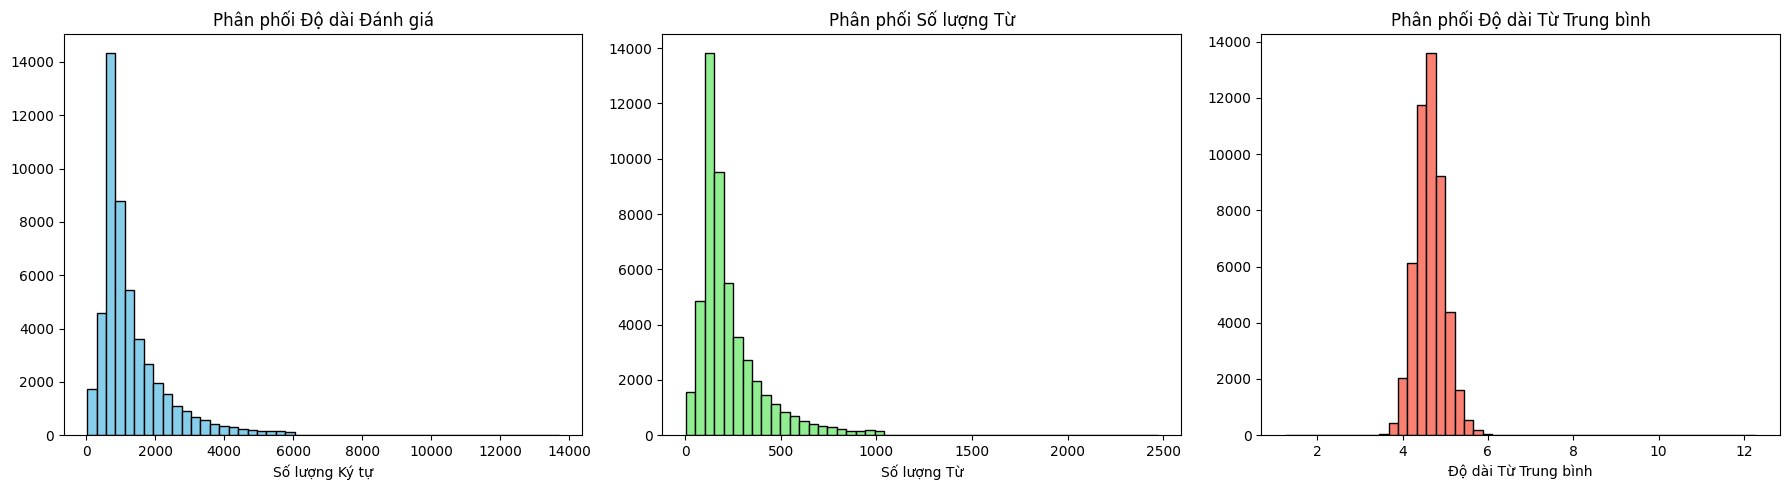

In [3]:
text_column = 'review'

# Tính toán các thống kê
df['text_length'] = df[text_column].str.len()
df['word_count'] = df[text_column].str.split().str.len()
df['avg_word_length'] = df[text_column].apply(
    lambda x: np.mean([len(word) for word in str(x).split()])
)

print("Thống kê Đánh giá (Review):")
print(df[['text_length', 'word_count', 'avg_word_length']].describe())

# Trực quan hóa các phân phối
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['text_length'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Phân phối Độ dài Đánh giá')
axes[0].set_xlabel('Số lượng Ký tự')

axes[1].hist(df['word_count'], bins=50, edgecolor='black', color='lightgreen')
axes[1].set_title('Phân phối Số lượng Từ')
axes[1].set_xlabel('Số lượng Từ')

axes[2].hist(df['avg_word_length'], bins=50, edgecolor='black', color='salmon')
axes[2].set_title('Phân phối Độ dài Từ Trung bình')
axes[2].set_xlabel('Độ dài Từ Trung bình')

plt.tight_layout()
plt.show()


### 3.2 Các review mẫu

In [4]:
for idx in range(5):
    print(f"\nMẫu thứ {idx+1} (Cảm xúc: {df['sentiment'].iloc[idx]}):")
    print(df[text_column].iloc[idx])
    print(f"Độ dài: {df['text_length'].iloc[idx]} ký tự, "
          f"{df['word_count'].iloc[idx]} từ")



Mẫu thứ 1 (Cảm xúc: positive):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appe

### 3.3 Nhận xét từ bước khám phá dữ liệu

Dựa vào các kết quả thống kê và trực quan hóa, ta có một số **Insights (Nhận định) cơ bản sau:**

1. **Về phân phối độ dài văn bản:** 
   - Đa số các review (từ Median đến 75th percentile) có độ dài rơi vào khoảng $970$ đến $1590$ ký tự, tương đương với $173$ đến $280$ từ. Điều này cho thấy trung bình một đánh giá phim có độ chi tiết và cung cấp ngữ cảnh khá đầy đủ, đủ dài để các mô hình học sâu (như RNN, Transformer) nắm bắt được cấu trúc ngữ nghĩa mấu chốt.
   - Tuy nhiên, độ lệch chuẩn (std) rất cao, cả về độ dài ký tự ($\sim989$) lẫn lượng từ ($\sim171$), đi kèm với giá trị chênh lệch quá lớn giữa review ngắn nhất (chỉ $4$ từ) và dài nhất ($2470$ từ). Sự khác biệt cực đoan này báo hiệu việc ta cần phải giới hạn số token tối đa (max\_length padding/truncation) khi chuyển đổi dữ liệu để tối ưu hóa quá trình tính toán trong tương lai.

2. **Về đặc trưng từ vựng:** 
   - Độ dài trung bình của một từ rất ổn định quanh mức $\sim4.6$ ký tự, hoàn toàn phù hợp với cấu trúc ngôn ngữ của tiếng Anh phổ thông.
   - Trong quá trình in các review đặc trưng (Data Sampling), có thể thấy xuất hiện rất nhiều thẻ HTML (`<br /><br />`) và các ký tự đặc biệt, dấu câu, đặc trưng thường thấy của văn bản trích xuất trực tiếp từ giao diện web (web-scraped text).

**$\Rightarrow$ Kết luận sơ bộ quy trình Tiền xử lý (Preprocessing Phase):** 
Dữ liệu đang chứa cực kỳ nhiều thành tố gây nhiễu. Cần áp dụng các giải pháp như loại bỏ HTML tags, loại bỏ stop words vô nghĩa, xử lý dấu câu và sử dụng Stemming/Lemmatization để đưa thông tin về cấu trúc tự nhiên dễ học nhất.


---

## 4. Tokenization

### 4.1 Lý do
**Tại sao cần tokenization:**
- Tokenization là bước cơ bản nhất trong xử lý ngôn ngữ tự nhiên, giúp chia nhỏ văn bản thành các đơn vị có nghĩa (tokens) như từ, câu, hoặc ký tự. Điều này tạo nền tảng cho các bước xử lý tiếp theo như loại bỏ stop words, stemming, và vector hóa.

**Các loại tokenization:**
1. **Word Tokenization:** Chia văn bản thành các từ riêng biệt. Phù hợp cho các mô hình dựa trên từ (word-level models).
2. **Subword Tokenization:** Chia từ thành các phần nhỏ hơn (ví dụ: "playing" -> "play", "ing"). Thường dùng trong các mô hình ngôn ngữ lớn (LLMs) như BERT để xử lý từ hiếm (out-of-vocabulary).
3. **Sentence Tokenization:** Chia văn bản thành các câu. Hữu ích khi ngữ cảnh của câu quan trọng (ví dụ: tóm tắt văn bản, dịch máy).

### 4.2 Cài đặt

In [5]:
def tokenize_words(text):
    """Tách văn bản thành các từ cơ bản"""
    return word_tokenize(text.lower())

def tokenize_sentences(text):
    """Tách văn bản thành các câu"""
    return sent_tokenize(text)

# Khởi tạo mô hình BPE tokenizer của OpenAI
enc = tiktoken.encoding_for_model("gpt-3.5-turbo")

def tokenize_subwords(text):
    """Tách văn bản thành các subwords sử dụng BPE"""
    tokens = enc.encode(text)
    return [enc.decode_single_token_bytes(t).decode('utf-8', errors='replace') for t in tokens]

df['words'] = df[text_column].apply(tokenize_words)
df['sentences'] = df[text_column].apply(tokenize_sentences)
df['subwords'] = df[text_column].apply(tokenize_subwords)

print("Đã hoàn thành Tokenization!")
print(f"\nVăn bản mẫu sau khi tokenize:")
print(f"Gốc: {df[text_column].iloc[0]}")
print(f"\nWord tokens: {df['words'].iloc[0]}")
print(f"\nSubword tokens: {df['subwords'].iloc[0]}")
print(f"\nSentence tokens: {df['sentences'].iloc[0]}")


Đã hoàn thành Tokenization!

Văn bản mẫu sau khi tokenize:
Gốc: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /

### 4.3 So sánh các phương pháp tokenization khác nhau

In [6]:
sample_text = df[text_column].iloc[0]

word_tokens = word_tokenize(sample_text)
sentence_tokens = sent_tokenize(sample_text)
subword_tokens = enc.encode(sample_text)
subword_tokens_text = [enc.decode_single_token_bytes(t).decode('utf-8', errors='replace') for t in subword_tokens]

print("So sánh Word Tokenization, Subword Tokenization và Sentence Tokenization:")
print(f"\nReview mẫu có tổng cộng {len(sample_text)} ký tự.")
print(f"Số lượng Word Tokens (từ): {len(word_tokens)}")
print(word_tokens)
print(f"\nSố lượng Subword Tokens (subword): {len(subword_tokens_text)}")
print(subword_tokens_text)
print(f"\nSố lượng Sentence Tokens (câu): {len(sentence_tokens)}")
print(sentence_tokens)


So sánh Word Tokenization, Subword Tokenization và Sentence Tokenization:

Review mẫu có tổng cộng 1761 ký tự.
Số lượng Word Tokens (từ): 380
['One', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', '1', 'Oz', 'episode', 'you', "'ll", 'be', 'hooked', '.', 'They', 'are', 'right', ',', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'me.', '<', 'br', '/', '>', '<', 'br', '/', '>', 'The', 'first', 'thing', 'that', 'struck', 'me', 'about', 'Oz', 'was', 'its', 'brutality', 'and', 'unflinching', 'scenes', 'of', 'violence', ',', 'which', 'set', 'in', 'right', 'from', 'the', 'word', 'GO', '.', 'Trust', 'me', ',', 'this', 'is', 'not', 'a', 'show', 'for', 'the', 'faint', 'hearted', 'or', 'timid', '.', 'This', 'show', 'pulls', 'no', 'punches', 'with', 'regards', 'to', 'drugs', ',', 'sex', 'or', 'violence', '.', 'Its', 'is', 'hardcore', ',', 'in', 'the', 'classic', 'use', 'of', 'the', 'word.', '<', 'br', '/', '>', '<', 'br', '/', '>', 'It', 'is

#### Phân tích:
**Ưu điểm và Ứng dụng của từng phương pháp:**
- Word Tokenization (Tách từ): Phá vỡ văn bản thành các đơn vị nhỏ nhất (từ, dấu câu). Đây là bước tối quan trọng để xây dựng từ vựng (vocabulary) trong các mô hình truyền thống (BoW/TF-IDF). Điểm yếu là gặp khó khăn với các từ hiếm hoặc từ mới (Out-of-Vocabulary).
- Subword Tokenization (BPE, WordPiece): Chia các từ phức tạp thành các đơn vị nhỏ hơn (subwords) như tiền tố, hậu tố hoặc các gốc từ phổ biến. Rất hiệu quả để xử lý hiện tượng Out-of-Vocabulary và là tiêu chuẩn cho các mô hình ngôn ngữ lớn (LLMs như BERT, GPT).
- Sentence Tokenization (Tách câu): Phá vỡ văn bản thành các câu hoàn chỉnh, giữ nguyên cấu trúc ngữ pháp. Phù hợp cho tóm tắt văn bản hoặc dịch máy.

**Sự phù hợp với Dataset IMDB:**
Đối với dataset IMDB nhằm mục đích chính là phân tích cảm xúc tích cực/tiêu cực:
- Nếu huấn luyện mô hình cơ bản (Naive Bayes, SVM) thì **Word Tokenization** là đủ tốt.
- Nếu sử dụng Deep Learning/Transformers để thu được độ chính xác tối đa, **Subword Tokenization (BPE)** sẽ là lựa chọn phù hợp nhất.

---

## 5. Loại bỏ Stop Words

### 5.1 Lý do
**Tại sao cần loại bỏ stop words:**
- Stop words là những từ xuất hiện rất thường xuyên nhưng mang ít ý nghĩa ngữ nghĩa (ví dụ: "the", "is", "in", "and"). Loại bỏ chúng giúp giảm kích thước từ vựng, tiết kiệm bộ nhớ và tính toán, đồng thời giúp mô hình tập trung vào các từ mang ý nghĩa quan trọng hơn.

**Khi nào nên/không nên loại bỏ:**
- Nên: Trong các bài toán phân loại văn bản (như phân tích cảm xúc), gom cụm văn bản, hoặc tìm kiếm thông tin, nơi ý nghĩa tổng thể quan trọng hơn cấu trúc ngữ pháp.
- Không nên: Trong các bài toán cần giữ lại cấu trúc ngữ pháp và ngữ cảnh chi tiết như dịch máy (Machine Translation), tóm tắt văn bản (Text Summarization), hoặc mô hình ngôn ngữ (Language Modeling).

### 5.2 Xác định Stop Words

In [7]:
stop_words = set(stopwords.words('english'))

# Nhận diện HTML tag bằng Regex dựa trên tần suất (Frequency-based)
tag_counts = Counter()
for text in df[text_column]:
    tags = re.findall(r'</?([a-zA-Z]+)\b[^>]*>', str(text))
    tag_counts.update([tag.lower() for tag in tags])

html_tags = {tag for tag, count in tag_counts.items() if count > 1000}

stop_words.update(html_tags)

print(f"Số lượng stop words: {len(stop_words)}")

# Phân tích stop words
all_words = []
for tokens in df['words']:
    all_words.extend(tokens)

word_freq = Counter(all_words)
most_common = word_freq.most_common(30)

print("\n30 từ xuất hiện nhiều nhất trong dataset:")
for word, count in most_common:
    is_stopword = "(STOP)" if word in stop_words else ""
    print(f"{word}: {count} {is_stopword}")

total_words = len(all_words)
stop_words_count = sum(count for word, count in word_freq.items() if word in stop_words)
print(f"\nTỉ lệ Stop words: {(stop_words_count / total_words) * 100:.2f}%")


Số lượng stop words: 199

30 từ xuất hiện nhiều nhất trong dataset:
the: 664213 (STOP)
,: 544030 
.: 464388 
and: 323076 (STOP)
a: 321254 (STOP)
of: 288526 (STOP)
to: 267033 (STOP)
is: 216900 (STOP)
/: 202455 
>: 202250 
<: 202094 
br: 201951 (STOP)
it: 187988 (STOP)
in: 185215 (STOP)
i: 173690 (STOP)
this: 150142 (STOP)
that: 143307 (STOP)
's: 122130 
was: 99809 (STOP)
as: 91549 (STOP)
with: 87121 (STOP)
for: 86928 (STOP)
movie: 85070 
but: 83182 (STOP)
film: 76919 
): 71268 
(: 69585 
you: 68673 (STOP)
on: 66870 (STOP)
'': 66435 

Tỉ lệ Stop words: 40.87%


### 5.3 Loại bỏ Stop Words

In [8]:
punctuations = set(string.punctuation)

def remove_stopwords_and_punct(tokens, stop_words, punctuations):
    """Loại bỏ stop words và dấu câu khỏi danh sách token"""
    return [word for word in tokens if word not in stop_words and word not in punctuations and word.isalpha()]

df['words_no_stop'] = df['words'].apply(
    lambda x: remove_stopwords_and_punct(x, stop_words, punctuations)
)

# So sánh trước và sau khi làm sạch
print(f"Ban đầu: {len(df['words'].iloc[0])} tokens")
print(f"{df['words'].iloc[0]}")
print(f"\nSau khi loại bỏ stop words và dấu câu: {len(df['words_no_stop'].iloc[0])} tokens")
print(f"{df['words_no_stop'].iloc[0]}")

# Thống kê
avg_reduction = (
    1 - df['words_no_stop'].str.len().mean() / df['words'].str.len().mean()
) * 100
print(f"\nTỉ lệ giảm trung bình số token: {avg_reduction:.1f}%")


Ban đầu: 380 tokens
['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', '1', 'oz', 'episode', 'you', "'ll", 'be', 'hooked', '.', 'they', 'are', 'right', ',', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'me.', '<', 'br', '/', '>', '<', 'br', '/', '>', 'the', 'first', 'thing', 'that', 'struck', 'me', 'about', 'oz', 'was', 'its', 'brutality', 'and', 'unflinching', 'scenes', 'of', 'violence', ',', 'which', 'set', 'in', 'right', 'from', 'the', 'word', 'go', '.', 'trust', 'me', ',', 'this', 'is', 'not', 'a', 'show', 'for', 'the', 'faint', 'hearted', 'or', 'timid', '.', 'this', 'show', 'pulls', 'no', 'punches', 'with', 'regards', 'to', 'drugs', ',', 'sex', 'or', 'violence', '.', 'its', 'is', 'hardcore', ',', 'in', 'the', 'classic', 'use', 'of', 'the', 'word.', '<', 'br', '/', '>', '<', 'br', '/', '>', 'it', 'is', 'called', 'oz', 'as', 'that', 'is', 'the', 'nickname', 'given', 'to', 'the', 'oswald', 'maximum', 'security', 'state', 

### 5.4 Phân tích tác động của việc loại bỏ stop words

Kích thước từ vựng (khi có stop words): 164030
Kích thước từ vựng (khi bỏ stop words): 96881
Số từ giảm đi: 67149 từ (40.9%)


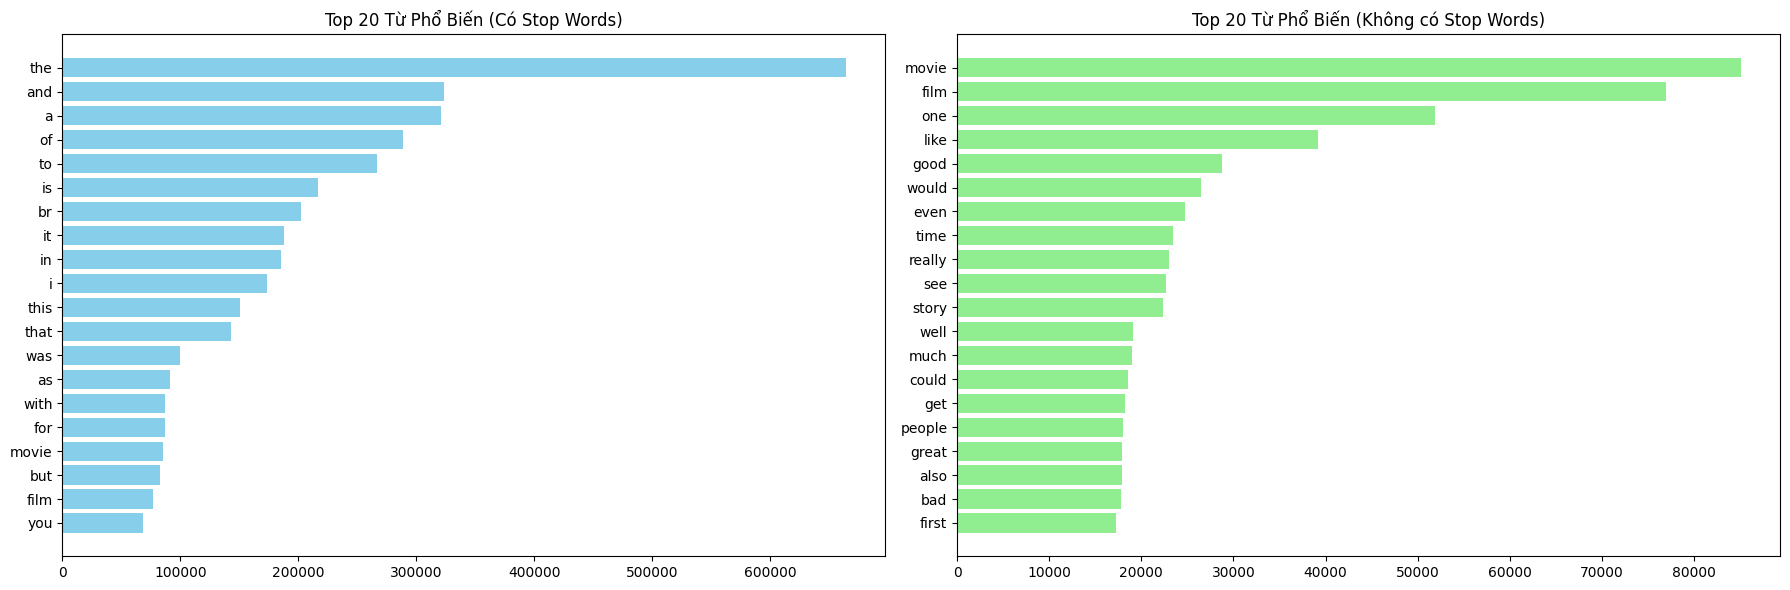

In [9]:
# So sánh kích thước từ vựng trên toàn bộ dataset
vocab_with_stop = set([word for tokens in df['words'] for word in tokens])
vocab_no_stop = set([word for tokens in df['words_no_stop'] for word in tokens])

print(f"Kích thước từ vựng (khi có stop words): {len(vocab_with_stop)}")
print(f"Kích thước từ vựng (khi bỏ stop words): {len(vocab_no_stop)}")
print(f"Số từ giảm đi: {len(vocab_with_stop) - len(vocab_no_stop)} từ "
      f"({((len(vocab_with_stop) - len(vocab_no_stop))/len(vocab_with_stop))*100:.1f}%)")

# Trực quan hóa các từ phổ biến nhất
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

words_with_stop = [word for tokens in df['words'] for word in tokens if word.isalpha()]
freq_with_stop = Counter(words_with_stop).most_common(20)

words_no_stop = [word for tokens in df['words_no_stop'] for word in tokens]
freq_no_stop = Counter(words_no_stop).most_common(20)

axes[0].barh([w[0] for w in freq_with_stop], [w[1] for w in freq_with_stop], color='skyblue')
axes[0].set_title('Top 20 Từ Phổ Biến (Có Stop Words)')
axes[0].invert_yaxis()

axes[1].barh([w[0] for w in freq_no_stop], [w[1] for w in freq_no_stop], color='lightgreen')
axes[1].set_title('Top 20 Từ Phổ Biến (Không có Stop Words)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


#### Phân tích:
- **Khả năng giữ lại thông tin:**
Sau khi loại bỏ stop words, các từ phổ biến nhất chuyển từ các từ chức năng (the, and, a, of, ...) sang các từ mang ý nghĩa thực sự liên quan đến phim ảnh (movie, film, one, like, good, ...). Điều này cho thấy thông tin quan trọng vẫn được giữ lại và thậm chí còn nổi bật hơn. Rất nên loại bỏ stop words cho dataset này vì mục tiêu chính là phân tích cảm xúc, nơi các từ mang ý nghĩa (tính từ, danh từ) quan trọng hơn các từ nối.

---

## 6. Rút gọn và Chuẩn hóa từ (Stemming and Lemmatization)

### 6.1 Lý do
**Mục đích:**
- Đưa các từ về dạng gốc hoặc dạng cơ bản của chúng, giúp giảm kích thước từ vựng và gom nhóm các từ có cùng ý nghĩa nhưng khác hình thái (ví dụ: "running", "runs" -> "run").

**Rút gọn (Stemming) vs Chuẩn hóa (Lemmatization):**
- **Stemming:** Cắt bỏ các hậu tố của từ dựa trên các quy tắc heuristic (ví dụ: bỏ "ing", "ed"). Nhanh nhưng có thể tạo ra các từ không có nghĩa (ví dụ: "studies" -> "studi").
- **Lemmatization:** Sử dụng từ điển và phân tích hình thái học để đưa từ về dạng gốc có nghĩa (lemma). Chậm hơn nhưng chính xác hơn (ví dụ: "studies" -> "study", "better" -> "good").

### 6.2 Rút gọn từ (Stemming)

In [10]:
porter = PorterStemmer()
snowball = SnowballStemmer('english')

def apply_stemming(tokens, stemmer):
    """Áp dụng cắt hậu tố cho các token"""
    return [stemmer.stem(word) for word in tokens]

df['tokens_porter'] = df['words_no_stop'].apply(
    lambda x: apply_stemming(x, porter)
)

df['tokens_snowball'] = df['words_no_stop'].apply(
    lambda x: apply_stemming(x, snowball)
)

print("Ví dụ về Rút gọn từ:")
sample_words = df['words_no_stop'].iloc[0][:10]
print(f"\nTừ gốc: {sample_words}")
print(f"Porter: {[porter.stem(w) for w in sample_words]}")
print(f"Snowball: {[snowball.stem(w) for w in sample_words]}")


Ví dụ về Rút gọn từ:

Từ gốc: ['one', 'reviewers', 'mentioned', 'watching', 'oz', 'episode', 'hooked', 'right', 'exactly', 'happened']
Porter: ['one', 'review', 'mention', 'watch', 'oz', 'episod', 'hook', 'right', 'exactli', 'happen']
Snowball: ['one', 'review', 'mention', 'watch', 'oz', 'episod', 'hook', 'right', 'exact', 'happen']


### 6.3 Chuẩn hóa từ (Lemmatization)

In [11]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    """Chuyển đổi các nhãn ngữ pháp (POS tags) của nltk thành POS tag định dạng cho WordNet Lemmatizer"""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def apply_lemmatization(tokens):
    """Áp dụng tìm gốc từ cho token kết hợp với tagging ngữ pháp từ"""
    tagged_tokens = pos_tag(tokens)
    return [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged_tokens]

df['tokens_lemma'] = df['words_no_stop'].apply(apply_lemmatization)

print("Ví dụ về Chuẩn hóa từ:")
print(f"\nTừ gốc: {sample_words}")
print(f"Từ sau khi chuẩn hóa: {apply_lemmatization(sample_words)}")


Ví dụ về Chuẩn hóa từ:

Từ gốc: ['one', 'reviewers', 'mentioned', 'watching', 'oz', 'episode', 'hooked', 'right', 'exactly', 'happened']
Từ sau khi chuẩn hóa: ['one', 'reviewer', 'mention', 'watch', 'oz', 'episode', 'hook', 'right', 'exactly', 'happen']


### 6.4 So sánh các phương pháp

In [12]:
# Các từ thử nghiệm
test_words = ['running', 'runs', 'ran', 'easily', 'fairly', 'studies', 'studying', 'better']

print("Bảng so sánh:")
print(f"{'Từ gốc':<15} {'Porter':<15} {'Snowball':<15} {'Lemmatizer (với POS-tag)':<25}")
print("="*75)

# Gắn tag tự động cho test_words
tagged_test_words = pos_tag(test_words)

for i in range(len(test_words)):
    word = test_words[i]
    tag = tagged_test_words[i][1]
        
    lemma = lemmatizer.lemmatize(word, pos=get_wordnet_pos(tag))
    
    print(f"{word:<15} {porter.stem(word):<15} "
          f"{snowball.stem(word):<15} {lemma:<25}")

# So sánh kích thước từ vựng giữa các phương pháp
vocab_original = len(set([w for tokens in df['words_no_stop'] for w in tokens]))
vocab_porter = len(set([w for tokens in df['tokens_porter'] for w in tokens]))
vocab_snowball = len(set([w for tokens in df['tokens_snowball'] for w in tokens]))
vocab_lemma = len(set([w for tokens in df['tokens_lemma'] for w in tokens]))

print(f"\nSo sánh kích thước từ vựng:")
print(f"Ban đầu (sau khi loại bỏ stop words): {vocab_original}")
print(f"Cắt hậu tố (Porter): {vocab_porter} (giảm được {((vocab_original-vocab_porter)/vocab_original)*100:.1f}%)")
print(f"Cắt hậu tố (Snowball): {vocab_snowball} (giảm được {((vocab_original-vocab_snowball)/vocab_original)*100:.1f}%)")
print(f"Tìm gốc từ (Lemmatization chuẩn POS-tag): {vocab_lemma} (giảm được {((vocab_original-vocab_lemma)/vocab_original)*100:.1f}%)")


Bảng so sánh:
Từ gốc          Porter          Snowball        Lemmatizer (với POS-tag) 
running         run             run             run                      
runs            run             run             run                      
ran             ran             ran             run                      
easily          easili          easili          easily                   
fairly          fairli          fair            fairly                   
studies         studi           studi           study                    
studying        studi           studi           study                    
better          better          better          well                     

So sánh kích thước từ vựng:
Ban đầu (sau khi loại bỏ stop words): 96881
Cắt hậu tố (Porter): 67346 (giảm được 30.5%)
Cắt hậu tố (Snowball): 66573 (giảm được 31.3%)
Tìm gốc từ (Lemmatization chuẩn POS-tag): 86609 (giảm được 10.6%)


#### Phân tích:
**Ưu và nhược điểm:**

| Method | Ưu điểm | Nhược điểm | Phù hợp với |
|--------|---------|------------|-------------|
| Porter Stemming | Nhanh, đơn giản, giảm kích thước từ vựng tốt | Tạo ra các từ không có nghĩa (ví dụ: easily -> easili) | Các ứng dụng cần tốc độ, tìm kiếm thông tin cơ bản |
| Snowball Stemming | Nhanh, cải tiến từ Porter, hỗ trợ nhiều ngôn ngữ | Vẫn có thể tạo ra từ không có nghĩa | Tương tự Porter nhưng tốt hơn một chút |
| Lemmatization với POS-tagger | Tạo ra các từ có nghĩa thực sự, chuyển đổi chính xác các thì (ran -> run) | Chậm hơn, cần tính toán thêm bước tag ngữ pháp | Phân tích cảm xúc, chatbot, các bài toán cần hiểu ngữ nghĩa sâu |

**Lựa chọn tốt nhất cho bộ dữ liệu này:**
Lemmatization kết hợp với POS-tagger (xác định từ loại) là lựa chọn hoàn hảo nhất, giúp đưa toàn bộ động từ chia quá khứ hay tính từ so sánh hơn về đúng nguyên thể ban đầu.

---

## 7. Text Vectorization

### 7.1 Lý do
**Tại sao cần vectorization:**
- Các mô hình Machine Learning không thể hiểu trực tiếp văn bản thô. Vectorization là quá trình chuyển đổi văn bản thành các vector số học để mô hình có thể xử lý và học các mẫu (patterns).

**Các phương pháp:**
1. **Bag of Words (BoW):** Đếm số lần xuất hiện của mỗi từ trong văn bản. Đơn giản nhưng bỏ qua thứ tự từ và ngữ cảnh.
2. **TF-IDF:** Đánh giá tầm quan trọng của một từ trong văn bản dựa trên tần suất xuất hiện của nó trong văn bản đó (TF) và nghịch đảo tần suất xuất hiện trong toàn bộ tập dữ liệu (IDF). Giúp giảm trọng số của các từ phổ biến và tăng trọng số của các từ đặc trưng.
3. **Word Embeddings:** Biểu diễn từ dưới dạng vector dày đặc (dense vector) trong không gian nhiều chiều, giữ lại được mối quan hệ ngữ nghĩa giữa các từ (ví dụ: Word2Vec, GloVe).

### 7.2 Bag of Words

In [13]:
df['text_processed'] = df['tokens_lemma'].apply(lambda x: ' '.join(x))

bow_vectorizer = CountVectorizer(
    max_features=1000,
    ngram_range=(1, 1)
)

bow_matrix = bow_vectorizer.fit_transform(df['text_processed'])

print("Kết quả Bag of Words:")
print(f"Kích thước ma trận (Shape): {bow_matrix.shape}")
print(f"Độ thưa của ma trận (Sparsity): {(1 - (bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1])))*100:.2f}%")

print(f"\nĐặc trưng trích xuất mẫu (Sample features): {bow_vectorizer.get_feature_names_out()[:20]}")

bow_df = pd.DataFrame(
    bow_matrix[:5].toarray(),
    columns=bow_vectorizer.get_feature_names_out()
)
print("\nBảng biểu diễn BoW cho 5 review đầu tiên:")
display(bow_df.head())


Kết quả Bag of Words:
Kích thước ma trận (Shape): (50000, 1000)
Độ thưa của ma trận (Sparsity): 94.42%

Đặc trưng trích xuất mẫu (Sample features): ['ability' 'able' 'absolutely' 'accent' 'accept' 'across' 'act' 'action'
 'actor' 'actress' 'actual' 'actually' 'adaptation' 'add' 'admit' 'adult'
 'adventure' 'age' 'agent' 'ago']

Bảng biểu diễn BoW cho 5 review đầu tiên:


,ability,able,absolutely,accent,accept,across,act,action,actor,actress,...,write,writer,wrong,yeah,year,yes,yet,york,young,zombie
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0


### 7.3 TF-IDF

In [14]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['text_processed'])

print("Kết quả TF-IDF:")
print(f"Kích thước ma trận (Shape): {tfidf_matrix.shape}")
print(f"Độ thưa của ma trận (Sparsity): {(1 - (tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])))*100:.2f}%")

tfidf_df = pd.DataFrame(
    tfidf_matrix[:5].toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
print("\nBảng biểu diễn TF-IDF cho 5 review đầu tiên:")
display(tfidf_df.head())


Kết quả TF-IDF:
Kích thước ma trận (Shape): (50000, 1000)
Độ thưa của ma trận (Sparsity): 94.36%

Bảng biểu diễn TF-IDF cho 5 review đầu tiên:


,ability,able,absolutely,accent,accept,across,act,action,actor,actress,...,wrong,yeah,year,year ago,year old,yes,yet,york,young,zombie
0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.098232,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.098919,0.0,0.0,0.0,0.0,0.000000,0.115174,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.180327
4,0.0,0.0,0.0,0.0,0.0,0.0,0.070641,0.100219,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.143423,0.000000,0.000000


### 7.4 Word Embeddings

In [15]:
word2vec_model = Word2Vec(
    sentences=df['tokens_lemma'].tolist(),
    vector_size=100,  
    window=5,        
    min_count=2,      
    workers=4         
)

print(f"Kích thước từ vựng: {len(word2vec_model.wv)}")
print(f"Kích thước vector: {word2vec_model.wv.vector_size}")

test_word = 'good'
if test_word in word2vec_model.wv:
    similar = word2vec_model.wv.most_similar(test_word, topn=5)
    print(f"\nCác từ có ngữ nghĩa tương đương với '{test_word}':")
    for word, score in similar:
        print(f"  {word}: (Độ tương đồng: {score:.3f})")


Kích thước từ vựng: 51646
Kích thước vector: 100

Các từ có ngữ nghĩa tương đương với 'good':
  decent: (Độ tương đồng: 0.787)
  great: (Độ tương đồng: 0.682)
  bad: (Độ tương đồng: 0.654)
  well: (Độ tương đồng: 0.639)
  alright: (Độ tương đồng: 0.629)


### 7.5 So sánh các phương pháp

| Aspect | BoW | TF-IDF | Word2Vec |
|--------|-----|--------|---------------------|
| Số chiều/Độ dài đặc trưng | Rất lớn (phụ thuộc vào max_features/số lượng từ) | Rất lớn (tương đương BoW) | Rất nhỏ và cố định |
| Loại vector | Ma trận thưa, cực kì nhiều số 0 | Ma trận thưa, cực kì nhiều số 0 | Ma trận đặc, mọi số đều mang ý nghĩa thực |
| Ý nghĩa thể hiện | Đếm số lượng, từ phổ biến có giá trị cao nhất | Đánh giá mức độ quan trọng, giảm trọng số từ phổ biến, tăng trọng số từ hiếm có đặc trưng phân loại | Định lượng hóa quan hệ ngữ nghĩa, khoảng cách giữa 2 từ càng ngắn nghĩa là chúng được dùng trong ngữ cảnh giống nhau |
| Ngữ cảnh | Bị phá hủy hoàn toàn (mất thứ tự từ) | Bị phá hủy hoàn toàn | Được bảo toàn (do học qua cửa sổ window lân cận) |
| Best use case | Thuật toán Machine Learning gốc (Naive Bayes, SVM) dễ train, dễ hiểu | Phân loại văn bản (Text Classification / Sentiment Analysis) theo mô hình truyền thống | Thuật toán Deep Learning nâng cao (LSTM, TCN, Transformers, CNN 1D) |
